In [1]:
import pandas as pd

path = r"C:\DEEP LEARNING\final project deep learning\archive (2)\METABRIC_RNA_Mutation.csv"
df = pd.read_csv(path, low_memory=False)

df.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,...,0,0,0,0,0,0,0,0,0,0


In [2]:
df.shape

(1904, 693)

In [4]:
for col in df.columns:
    print(col)

patient_id
age_at_diagnosis
type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
neoplasm_histologic_grade
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
lymph_nodes_examined_positive
mutation_count
nottingham_prognostic_index
oncotree_code
overall_survival_months
overall_survival
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_size
tumor_stage
death_from_cancer
brca1
brca2
palb2
pten
tp53
atm
cdh1
chek2
nbn
nf1
stk11
bard1
mlh1
msh2
msh6
pms2
epcam
rad51c
rad51d
rad50
rb1
rbl1
rbl2
ccna1
ccnb1
cdk1
ccne1
cdk2
cdc25a
ccnd1
cdk4
cdk6
ccnd2
cdkn2a
cdkn2b
myc
cdkn1a
cdkn1b
e2f1
e2f2
e2f3
e2f4
e2f5
e2f6
e2f7
e2f8
src
jak1
jak2
stat1
stat2
stat3
stat5a
stat5b
mdm2
tp53bp1
adam10
adam17
aph1a
aph1b
arrdc1
cir1
ctbp1
ctbp2
cul1
dll1
dll3
dll4
dtx1
dtx2
dtx3
dtx4
ep300
fbxw7
hda

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(496), int64(7), object(190)
memory usage: 10.1+ MB


In [6]:
df["pam50_+_claudin-low_subtype"].unique()

array(['claudin-low', 'LumA', 'LumB', 'Her2', 'Normal', 'Basal', 'NC'],
      dtype=object)

In [7]:
df = df[df["pam50_+_claudin-low_subtype"] != "claudin-low"]

In [8]:
df = df[~df["pam50_+_claudin-low_subtype"].isin(["Normal", "NC"])]

In [9]:
df["pam50_+_claudin-low_subtype"].value_counts()

pam50_+_claudin-low_subtype
LumA     679
LumB     461
Her2     220
Basal    199
Name: count, dtype: int64

In [10]:
mutation_cols = [col for col in df.columns if col.endswith("_mut")]

# count
len(mutation_cols)

# print names
for col in mutation_cols:
    print(col)

pik3ca_mut
tp53_mut
muc16_mut
ahnak2_mut
kmt2c_mut
syne1_mut
gata3_mut
map3k1_mut
ahnak_mut
dnah11_mut
cdh1_mut
dnah2_mut
kmt2d_mut
ush2a_mut
ryr2_mut
dnah5_mut
herc2_mut
pde4dip_mut
akap9_mut
tg_mut
birc6_mut
utrn_mut
tbx3_mut
col6a3_mut
arid1a_mut
lama2_mut
notch1_mut
cbfb_mut
ncor2_mut
col12a1_mut
col22a1_mut
pten_mut
akt1_mut
atr_mut
thada_mut
ncor1_mut
stab2_mut
myh9_mut
runx1_mut
nf1_mut
map2k4_mut
ros1_mut
lamb3_mut
arid1b_mut
erbb2_mut
sf3b1_mut
shank2_mut
ep300_mut
ptprd_mut
usp9x_mut
setd2_mut
setd1a_mut
thsd7a_mut
afdn_mut
erbb3_mut
rb1_mut
myo1a_mut
alk_mut
fanca_mut
adgra2_mut
ubr5_mut
pik3r1_mut
myo3a_mut
asxl2_mut
apc_mut
ctcf_mut
asxl1_mut
fancd2_mut
taf1_mut
kdm6a_mut
ctnna3_mut
brca1_mut
ptprm_mut
foxo3_mut
usp28_mut
gldc_mut
brca2_mut
cacna2d3_mut
arid2_mut
aff2_mut
lifr_mut
sbno1_mut
kdm3a_mut
ncoa3_mut
bap1_mut
l1cam_mut
pbrm1_mut
chd1_mut
jak1_mut
setdb1_mut
fam20c_mut
arid5b_mut
egfr_mut
map3k10_mut
smarcc2_mut
erbb4_mut
npnt_mut
nek1_mut
agmo_mut
zfp36l1_mut
sma

In [11]:
len(mutation_cols)

173

In [12]:
clinical_cols = [
    'age_at_diagnosis',
    'type_of_breast_surgery',
    'cancer_type',
    'cancer_type_detailed',
    'cellularity',
    'chemotherapy',
    'cohort',
    'er_status_measured_by_ihc',
    'er_status',
    'neoplasm_histologic_grade',
    'her2_status_measured_by_snp6',
    'her2_status',
    'tumor_other_histologic_subtype',
    'hormone_therapy',
    'inferred_menopausal_state',
    'integrative_cluster',
    'primary_tumor_laterality',
    'lymph_nodes_examined_positive',
    'mutation_count',
    'nottingham_prognostic_index',
    'oncotree_code',
    'pr_status',
    'radio_therapy',
    '3-gene_classifier_subtype',
    'tumor_size',
    'tumor_stage'
]

In [13]:
gene_cols = [
    col for col in df.columns 
    if col not in clinical_cols 
    and not col.endswith("_mut") 
    and col not in [
        "patient_id",
        "pam50_+_claudin-low_subtype",
        "overall_survival",
        "overall_survival_months",
        "death_from_cancer"
    ]
]

In [14]:
len(gene_cols)

489

In [15]:
X_clinical = df[clinical_cols]
y = df["pam50_+_claudin-low_subtype"]

In [16]:
X_clinical.head()

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,...,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage
1,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,1,Positve,Positive,3.0,...,Right,0,2.0,4.020,IDC,Positive,1,ER+/HER2- High Prolif,10.0,1.0
2,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,1,Positve,Positive,2.0,...,Right,1,2.0,4.030,IDC,Positive,0,NaN,15.0,2.0
3,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,1,Positve,Positive,2.0,...,Right,3,1.0,4.050,MDLC,Positive,1,NaN,25.0,2.0
4,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,1,Positve,Positive,3.0,...,Right,8,2.0,6.080,MDLC,Positive,1,ER+/HER2- High Prolif,40.0,2.0
5,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,1,Positve,Positive,3.0,...,Left,0,4.0,4.062,IDC,Positive,1,ER+/HER2- High Prolif,31.0,4.0


In [17]:
X_clinical = X_clinical.drop(columns=["3-gene_classifier_subtype"])

In [18]:
len(X_clinical.columns)

25

In [19]:
X_clinical.isnull().sum()

age_at_diagnosis                    0
type_of_breast_surgery             15
cancer_type                         0
cancer_type_detailed               12
cellularity                        28
chemotherapy                        0
cohort                              0
er_status_measured_by_ihc          25
er_status                           0
neoplasm_histologic_grade          57
her2_status_measured_by_snp6        0
her2_status                         0
tumor_other_histologic_subtype     12
hormone_therapy                     0
inferred_menopausal_state           0
integrative_cluster                 0
primary_tumor_laterality           86
lymph_nodes_examined_positive       0
mutation_count                     20
nottingham_prognostic_index         0
oncotree_code                      12
pr_status                           0
radio_therapy                       0
tumor_size                         12
tumor_stage                       420
dtype: int64

In [20]:
X_clinical.shape

(1559, 25)

In [21]:
for col in X_clinical.columns:
    if X_clinical[col].dtype == 'object':
        X_clinical[col] = X_clinical[col].fillna(X_clinical[col].mode()[0])
    else:
        X_clinical[col] = X_clinical[col].fillna(X_clinical[col].median())

In [22]:
X_clinical.isnull().sum()

age_at_diagnosis                  0
type_of_breast_surgery            0
cancer_type                       0
cancer_type_detailed              0
cellularity                       0
chemotherapy                      0
cohort                            0
er_status_measured_by_ihc         0
er_status                         0
neoplasm_histologic_grade         0
her2_status_measured_by_snp6      0
her2_status                       0
tumor_other_histologic_subtype    0
hormone_therapy                   0
inferred_menopausal_state         0
integrative_cluster               0
primary_tumor_laterality          0
lymph_nodes_examined_positive     0
mutation_count                    0
nottingham_prognostic_index       0
oncotree_code                     0
pr_status                         0
radio_therapy                     0
tumor_size                        0
tumor_stage                       0
dtype: int64

In [23]:
X_clinical_encoded = pd.get_dummies(X_clinical, drop_first=True)

In [24]:
X_clinical_encoded.shape

(1559, 47)

In [25]:
X_clinical_encoded.columns

Index(['age_at_diagnosis', 'chemotherapy', 'cohort',
       'neoplasm_histologic_grade', 'hormone_therapy',
       'lymph_nodes_examined_positive', 'mutation_count',
       'nottingham_prognostic_index', 'radio_therapy', 'tumor_size',
       'tumor_stage', 'type_of_breast_surgery_MASTECTOMY',
       'cancer_type_detailed_Breast Invasive Ductal Carcinoma',
       'cancer_type_detailed_Breast Invasive Lobular Carcinoma',
       'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma',
       'cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma',
       'cellularity_Low', 'cellularity_Moderate',
       'er_status_measured_by_ihc_Positve', 'er_status_Positive',
       'her2_status_measured_by_snp6_LOSS',
       'her2_status_measured_by_snp6_NEUTRAL',
       'her2_status_measured_by_snp6_UNDEF', 'her2_status_Positive',
       'tumor_other_histologic_subtype_Lobular',
       'tumor_other_histologic_subtype_Medullary',
       'tumor_other_histologic_subtype_Mixed',
       't

In [26]:
X_clinical_encoded.head()

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,radio_therapy,tumor_size,...,integrative_cluster_6,integrative_cluster_7,integrative_cluster_8,integrative_cluster_9,primary_tumor_laterality_Right,oncotree_code_IDC,oncotree_code_ILC,oncotree_code_IMMC,oncotree_code_MDLC,pr_status_Positive
1,43.19,0,1,3.0,1,0,2.0,4.020,1,10.0,...,False,False,False,False,True,True,False,False,False,True
2,48.87,1,1,2.0,1,1,2.0,4.030,0,15.0,...,False,False,False,False,True,True,False,False,False,True
3,47.68,1,1,2.0,1,3,1.0,4.050,1,25.0,...,False,False,False,True,True,False,False,False,True,True
4,76.97,1,1,3.0,1,8,2.0,6.080,1,40.0,...,False,False,False,True,True,False,False,False,True,True
5,78.77,0,1,3.0,1,0,4.0,4.062,1,31.0,...,False,True,False,False,False,True,False,False,False,True


In [27]:
X_clinical_encoded.select_dtypes(include='object').columns

Index([], dtype='object')

In [31]:
import pandas as pd

pd.set_option('display.max_columns', None)
X_clinical_encoded.head()

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,radio_therapy,tumor_size,tumor_stage,type_of_breast_surgery_MASTECTOMY,cancer_type_detailed_Breast Invasive Ductal Carcinoma,cancer_type_detailed_Breast Invasive Lobular Carcinoma,cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma,cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma,cellularity_Low,cellularity_Moderate,er_status_measured_by_ihc_Positve,er_status_Positive,her2_status_measured_by_snp6_LOSS,her2_status_measured_by_snp6_NEUTRAL,her2_status_measured_by_snp6_UNDEF,her2_status_Positive,tumor_other_histologic_subtype_Lobular,tumor_other_histologic_subtype_Medullary,tumor_other_histologic_subtype_Mixed,tumor_other_histologic_subtype_Mucinous,tumor_other_histologic_subtype_Other,tumor_other_histologic_subtype_Tubular/ cribriform,inferred_menopausal_state_Pre,integrative_cluster_10,integrative_cluster_2,integrative_cluster_3,integrative_cluster_4ER+,integrative_cluster_4ER-,integrative_cluster_5,integrative_cluster_6,integrative_cluster_7,integrative_cluster_8,integrative_cluster_9,primary_tumor_laterality_Right,oncotree_code_IDC,oncotree_code_ILC,oncotree_code_IMMC,oncotree_code_MDLC,pr_status_Positive
1,43.19,0,1,3.0,1,0,2.0,4.020,1,10.0,1.0,False,True,False,False,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,True
2,48.87,1,1,2.0,1,1,2.0,4.030,0,15.0,2.0,True,True,False,False,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,True
3,47.68,1,1,2.0,1,3,1.0,4.050,1,25.0,2.0,True,False,False,False,True,False,True,True,True,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,True
4,76.97,1,1,3.0,1,8,2.0,6.080,1,40.0,2.0,True,False,False,False,True,False,False,True,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,True
5,78.77,0,1,3.0,1,0,4.0,4.062,1,31.0,4.0,True,True,False,False,False,False,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clinical_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())

(1247, 47)
(312, 47)
pam50_+_claudin-low_subtype
LumA     543
LumB     369
Her2     176
Basal    159
Name: count, dtype: int64


In [ ]:
############    Data exploration   ######################3

In [34]:
X_train.describe()

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,radio_therapy,tumor_size,tumor_stage
count,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000
mean,61.771917,0.183641,2.668003,2.390537,0.625501,2.001604,5.888532,4.026108,0.591820,26.470176,1.822775
std,13.040654,0.387346,1.202777,0.653923,0.484187,4.144462,4.391688,1.157387,0.491694,15.037317,0.547747
min,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.020000,0.000000,1.000000,0.000000
25%,52.730000,0.000000,2.000000,2.000000,0.000000,0.000000,3.000000,3.046000,0.000000,18.000000,2.000000
50%,62.610000,0.000000,3.000000,2.000000,1.000000,0.000000,5.000000,4.042000,1.000000,23.000000,2.000000
75%,71.180000,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.044000,1.000000,30.000000,2.000000
max,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,1.000000,182.000000,4.000000


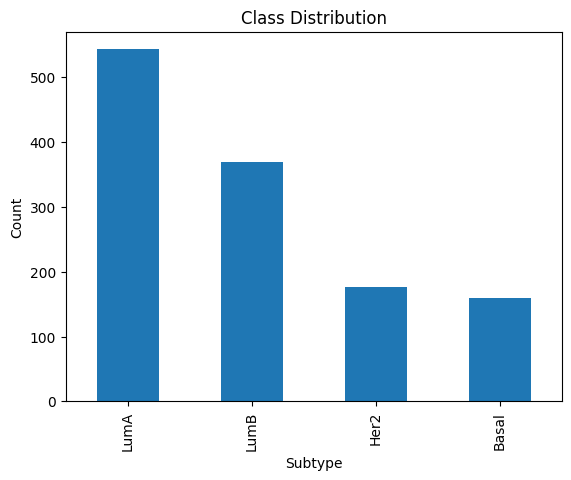

In [35]:
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.show()

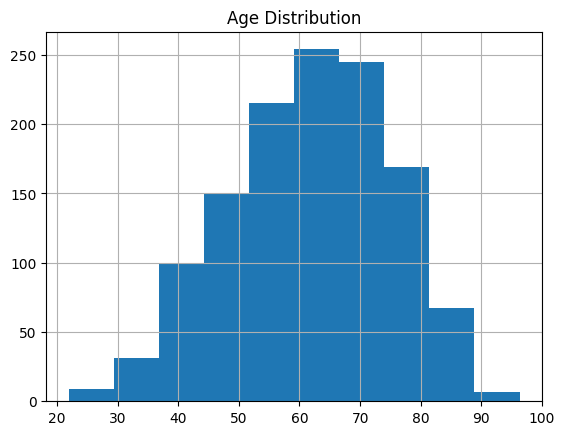

In [36]:
X_train["age_at_diagnosis"].hist()
plt.title("Age Distribution")
plt.show()

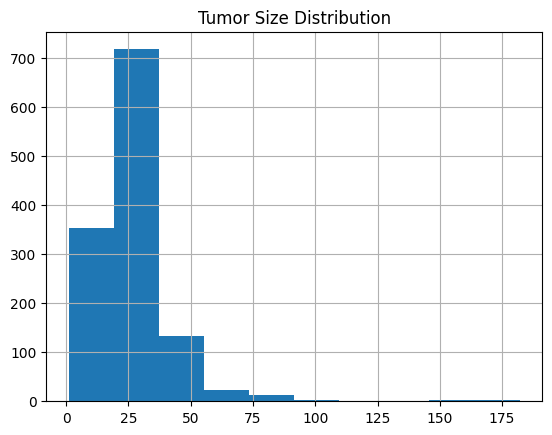

In [37]:
X_train["tumor_size"].hist()
plt.title("Tumor Size Distribution")
plt.show()

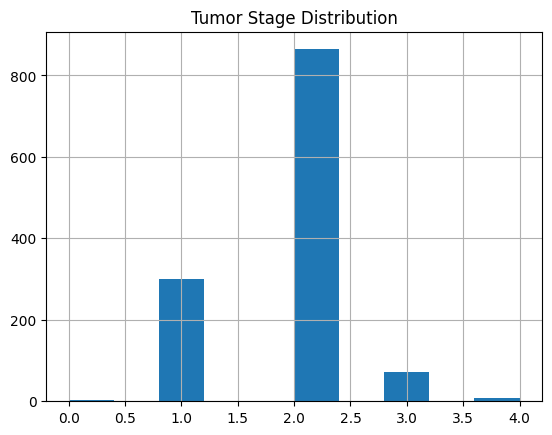

In [38]:
X_train["tumor_stage"].hist()
plt.title("Tumor Stage Distribution")
plt.show()

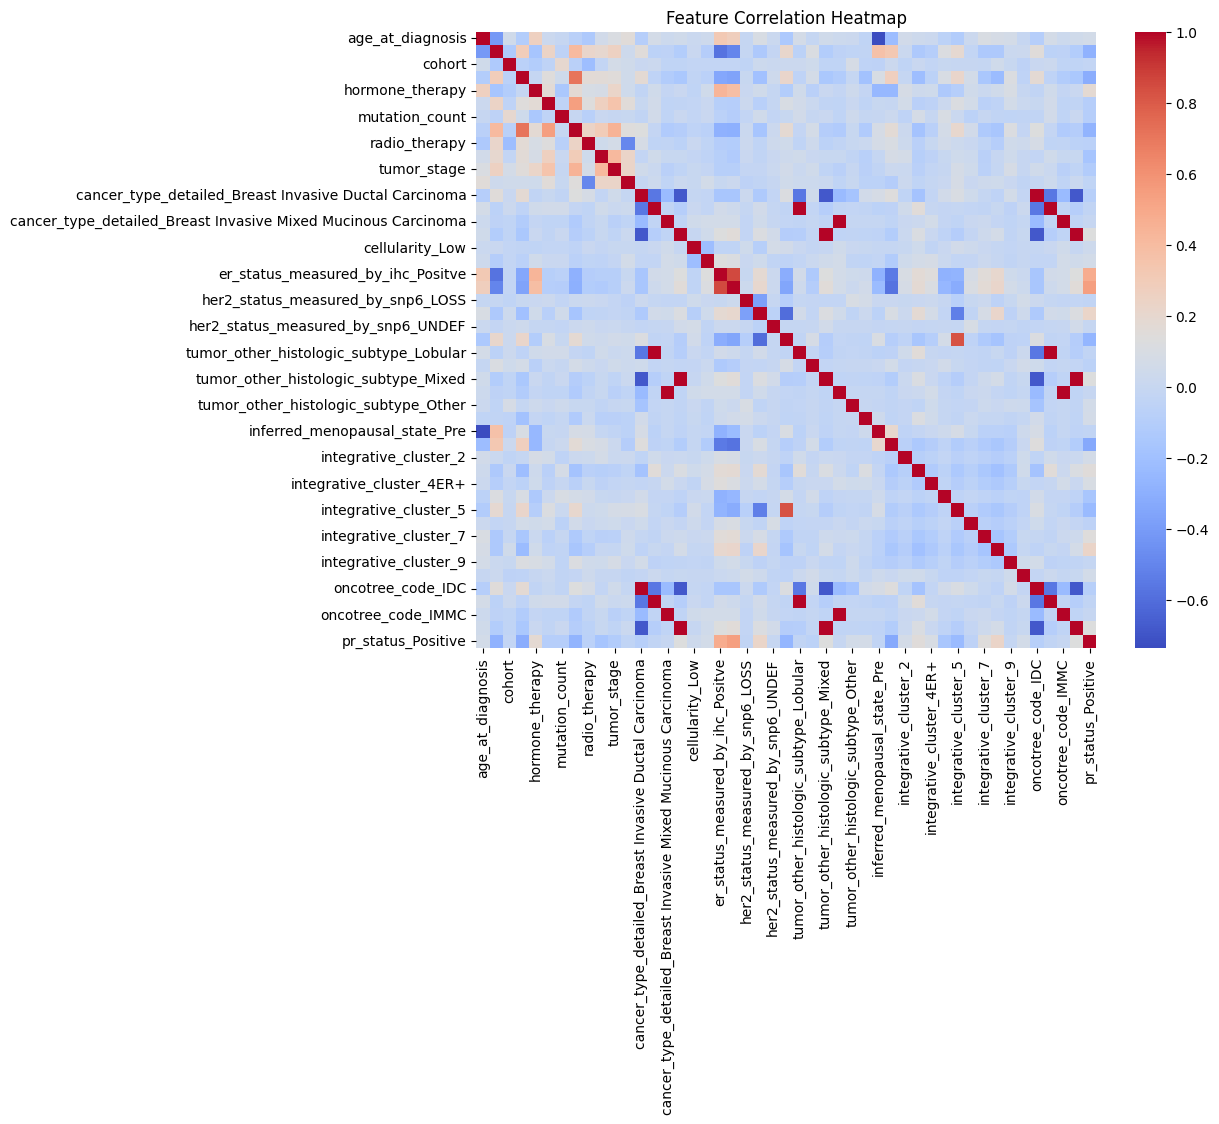

In [39]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(X_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [40]:
#Baseline MOdels

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)

y_pred_lr = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6698717948717948
              precision    recall  f1-score   support

       Basal       0.76      0.78      0.77        40
        Her2       0.54      0.68      0.60        44
        LumA       0.78      0.68      0.73       136
        LumB       0.57      0.60      0.59        92

    accuracy                           0.67       312
   macro avg       0.66      0.68      0.67       312
weighted avg       0.68      0.67      0.67       312



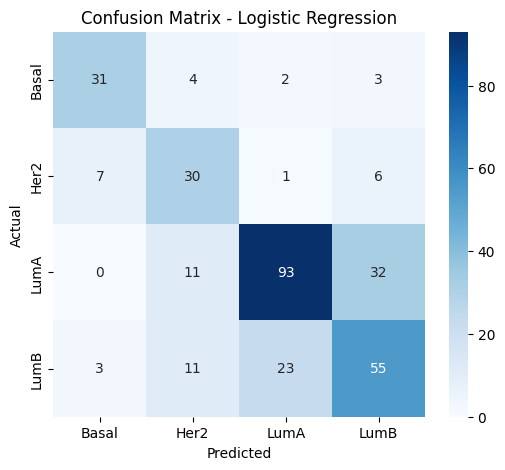

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
labels = ["Basal", "Her2", "LumA", "LumB"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'   # handles imbalance ✔
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6955128205128205
              precision    recall  f1-score   support

       Basal       0.80      0.80      0.80        40
        Her2       0.84      0.59      0.69        44
        LumA       0.69      0.81      0.74       136
        LumB       0.60      0.53      0.57        92

    accuracy                           0.70       312
   macro avg       0.73      0.68      0.70       312
weighted avg       0.70      0.70      0.69       312



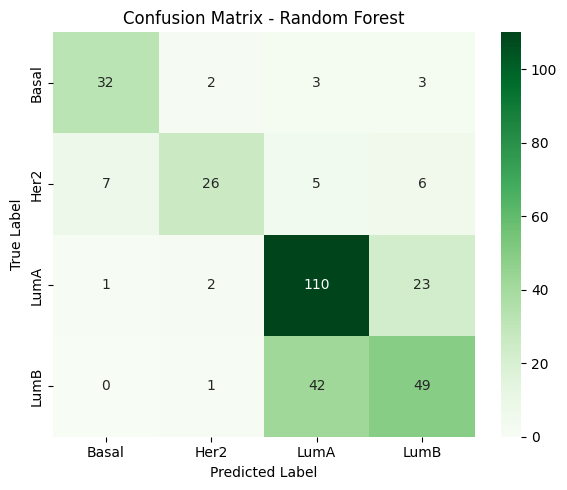

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

labels = ["Basal", "Her2", "LumA", "LumB"]

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.show()

In [45]:
###########################  Deep learning ############################

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clinical_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [49]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = MLP(input_size=X_train.shape[1], num_classes=4)

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [51]:
epochs = 20

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 1.3946
Epoch 10, Loss: 1.3438
Epoch 15, Loss: 1.2878
Epoch 20, Loss: 1.2215


In [52]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

In [53]:
from sklearn.metrics import accuracy_score, classification_report

print("MLP Accuracy:", accuracy_score(y_test, preds.numpy()))
print(classification_report(y_test, preds.numpy(), target_names=le.classes_))

MLP Accuracy: 0.5961538461538461
              precision    recall  f1-score   support

       Basal       0.69      0.68      0.68        40
        Her2       0.54      0.59      0.57        44
        LumA       0.59      0.90      0.72       136
        LumB       0.59      0.11      0.18        92

    accuracy                           0.60       312
   macro avg       0.60      0.57      0.54       312
weighted avg       0.60      0.60      0.53       312



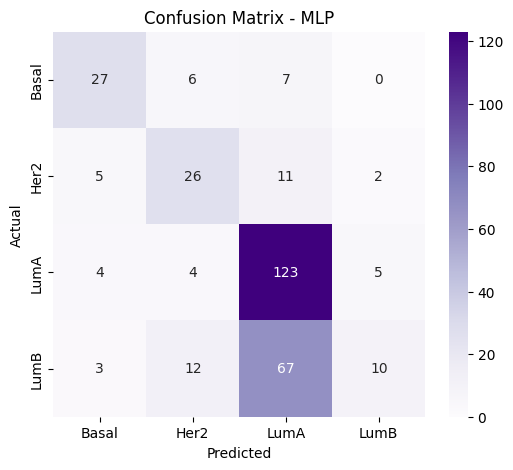

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds.numpy())

labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP")
plt.show()

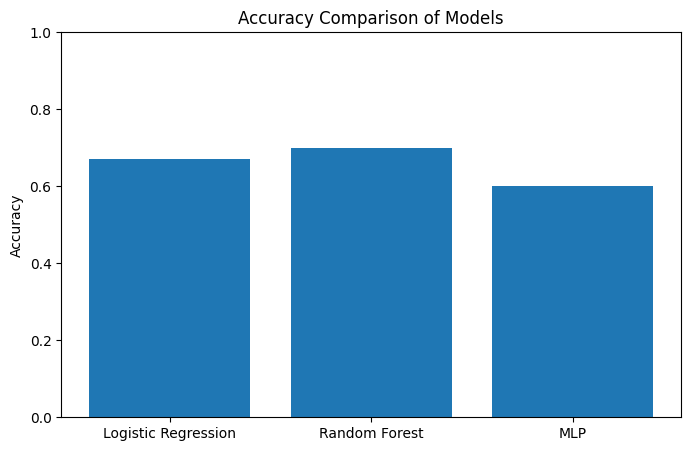

In [58]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "MLP"]
accuracies = [0.67, 0.70, 0.60]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

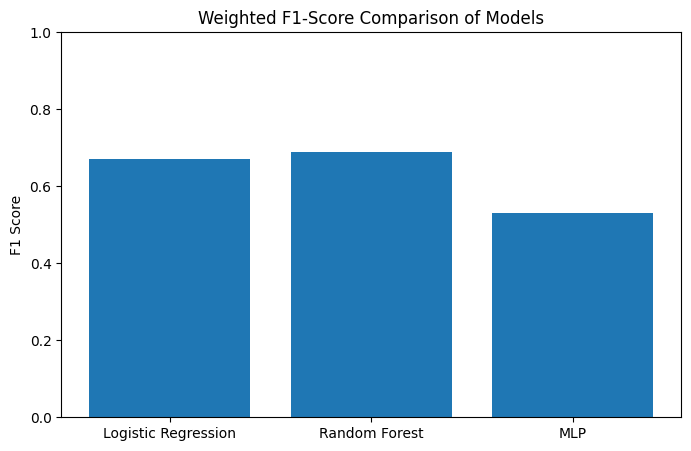

In [59]:
f1_scores = [0.67, 0.69, 0.53]

plt.figure(figsize=(8,5))
plt.bar(models, f1_scores)
plt.title("Weighted F1-Score Comparison of Models")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

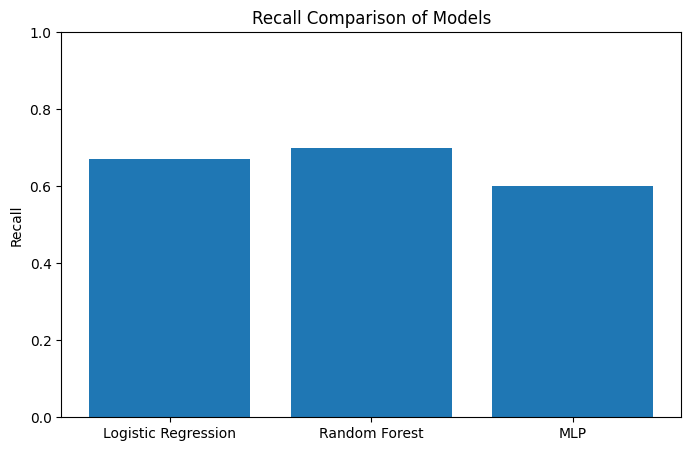

In [60]:
recalls = [0.67, 0.70, 0.60]

plt.figure(figsize=(8,5))
plt.bar(models, recalls)
plt.title("Recall Comparison of Models")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

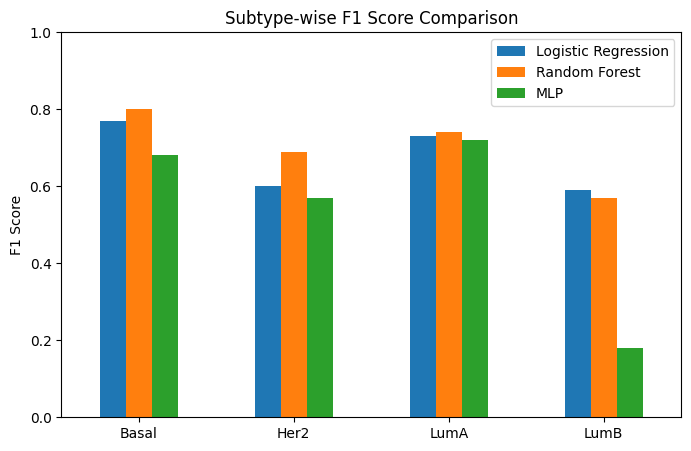

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

f1_df = pd.DataFrame({
    "Logistic Regression": [0.77, 0.60, 0.73, 0.59],
    "Random Forest": [0.80, 0.69, 0.74, 0.57],
    "MLP": [0.68, 0.57, 0.72, 0.18]
}, index=["Basal", "Her2", "LumA", "LumB"])

f1_df.plot(kind="bar", figsize=(8,5))
plt.title("Subtype-wise F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

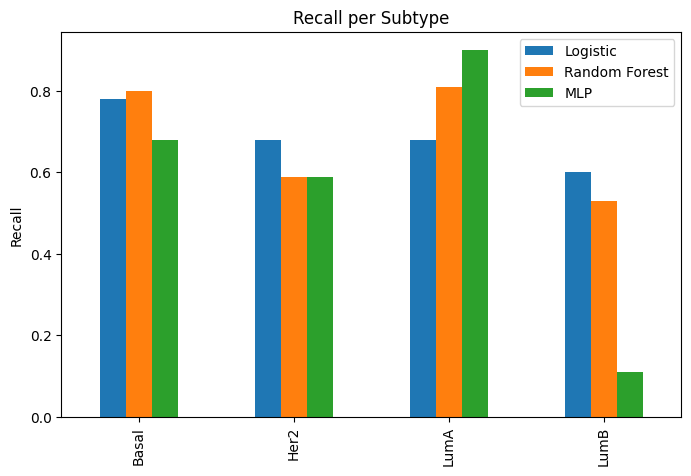

In [62]:
recall_df = pd.DataFrame({
    "Logistic": [0.78, 0.68, 0.68, 0.60],
    "Random Forest": [0.80, 0.59, 0.81, 0.53],
    "MLP": [0.68, 0.59, 0.90, 0.11]
}, index=["Basal", "Her2", "LumA", "LumB"])

recall_df.plot(kind="bar", figsize=(8,5))
plt.title("Recall per Subtype")
plt.ylabel("Recall")
plt.show()

In [63]:
X_train_ae = X_train
X_test_ae = X_test
import torch

X_train_ae_tensor = torch.tensor(X_train_ae, dtype=torch.float32)
X_test_ae_tensor = torch.tensor(X_test_ae, dtype=torch.float32)

import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

ae_model = Autoencoder(input_dim=X_train_ae.shape[1])

In [64]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=0.001)

In [65]:
epochs = 20
ae_losses = []

for epoch in range(epochs):
    ae_model.train()
    
    reconstructed = ae_model(X_train_ae_tensor)
    loss = criterion(reconstructed, X_train_ae_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    ae_losses.append(loss.item())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 1.0051
Epoch 10, Loss: 0.9981
Epoch 15, Loss: 0.9901
Epoch 20, Loss: 0.9804


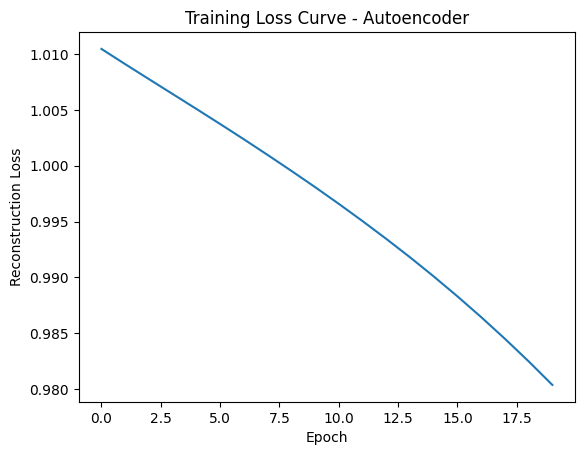

In [66]:
import matplotlib.pyplot as plt

plt.plot(ae_losses)
plt.title("Training Loss Curve - Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.show()

In [67]:
ae_model.eval()

with torch.no_grad():
    reconstructed_test = ae_model(X_test_ae_tensor)
    test_loss = criterion(reconstructed_test, X_test_ae_tensor)

print("Autoencoder Test Reconstruction Loss:", test_loss.item())

Autoencoder Test Reconstruction Loss: 0.9226939678192139


In [ ]:
###############validation step#########################

In [68]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

scores = cross_val_score(rf, X_clinical_encoded, y_encoded, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation scores: [0.70833333 0.69871795 0.68910256 0.68589744 0.65273312]
Mean CV accuracy: 0.6869568802044685


In [ ]:
##################################  Hyperparameter tuning#######################

In [69]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Random search
rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,         # small for speed
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Fit
rf_random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': None}


In [71]:
best_rf = rf_random.best_estimator_

from sklearn.metrics import accuracy_score, classification_report

y_pred_best = best_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned RF Accuracy: 0.7083333333333334
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        40
           1       0.81      0.57      0.67        44
           2       0.70      0.84      0.76       136
           3       0.63      0.53      0.58        92

    accuracy                           0.71       312
   macro avg       0.74      0.69      0.71       312
weighted avg       0.71      0.71      0.70       312

